# BTC 5m — Signal model v2 (`modelv2.py`)

Bốn model nhỏ, mỗi model một nhiệm vụ. Tất cả đo từ giá tham chiếu `open[t+1]` trên các nến `t+1..t+H`, với barrier `b = clip(k·σ·√H)`:

| Model | Dự báo | Train trên |
|---|---|---|
| **touch** | P(chạm `+b` hoặc `−b` trong H nến) | mọi mẫu |
| **dir** | P(`+b` trước `−b` \| có chạm) | mẫu đã chạm + ảnh gương |
| **ext** | P(`+2b` trước `−b` \| `+b` chạm trước) | mẫu đã chạm (đưa về chiều long) |
| **timeout** | E[R cuối horizon \| không chạm] | mẫu không chạm + ảnh gương |

Ghép lại thành **R kỳ vọng (trước phí)** của 4 mẫu lệnh: `long_1r`, `short_1r` (TP = b, SL = b) và `long_2r`, `short_2r` (TP = 2b, SL = b), tất cả cắt lệnh sau H nến. Đây là các giá trị dùng để thiết kế giao dịch ở bước backtest sau.

Đánh giá: walk-forward theo năm như v1. Các metric có khoảng tin cậy bootstrap theo khối ngày; R được báo cáo cả trước và sau phí; ngưỡng chọn tín hiệu lấy từ phần calibration (không nhìn trước test); có đếm tín hiệu không chồng lấn.

In [17]:
from pathlib import Path
from dataclasses import asdict, replace
import importlib
import json
import sys
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import roc_curve

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "model_training":
    PROJECT_ROOT = PROJECT_ROOT.parent
MODEL_DIR = PROJECT_ROOT / "model_training"
if str(MODEL_DIR) not in sys.path:
    sys.path.insert(0, str(MODEL_DIR))

try:
    import xgboost
except ImportError as exc:
    raise ImportError("Cần cài XGBoost: pip install xgboost  (khuyến nghị thêm numba)") from exc

import modelv2 as mv2
mv2 = importlib.reload(mv2)

warnings.filterwarnings("ignore", message=".*(No visible GPU|Device is changed|Falling back to prediction).*")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 220)
plt.style.use("seaborn-v0_8-whitegrid")
print("Model file :", Path(mv2.__file__).resolve())
print("Strategy   :", mv2.STRATEGY)
print("XGBoost    :", xgboost.__version__, "| numba:", mv2.HAVE_NUMBA)

Model file : C:\Users\thanh\BTC_PIPELINE\model_training\modelv2.py
Strategy   : touch_dir_ext_signal_v2
XGBoost    : 3.2.0 | numba: True


## CONFIG

Cell duy nhất cần chỉnh. `QUICK_RUN=True` chạy nhanh để kiểm tra (ít cây, 2 năm cuối, stride 3, ít vòng bootstrap), ghi ra thư mục `_quick` riêng.

`FEE_PCT_ROUNDTRIP` chỉ dùng khi đánh giá: 0.0008 = 0,04% × 2 (taker). Với lệnh maker có thể đặt khoảng 0.0004.

In [18]:
# ============================== CONFIG ==============================
QUICK_RUN = False

CSV_PATH = PROJECT_ROOT / "historical_data" / "BTCUSDT_5m_all.csv"
OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "5m_xgboost_signal_v2"
FEE_PCT_ROUNDTRIP = 0.0008

cfg = mv2.Config(
    csv_path=str(CSV_PATH),
    output_dir=str(OUTPUT_DIR),

    # ---- barrier / nhãn
    bar_minutes=5,
    pivot_reversal=0.005,
    pivot_count=8,
    lookback_bars=288,
    barrier_horizon=48,
    barrier_vol_mult=1.0,
    min_barrier=0.007,
    max_barrier=0.03,
    ext_mult=2.0,
    vol_span=288,
    slow_vol_span=2880,
    sample_stride=1,

    # ---- feature
    touch_groups=tuple(mv2.TOUCH_GROUPS),
    dir_groups=tuple(mv2.DIR_GROUPS),
    dir_zz_scales=(0.5, 1.0, 2.0, 4.0),

    # ---- giao thức
    eval_years=(2022, 2023, 2024, 2025, 2026),
    val_es_frac=0.6,

    # ---- huấn luyện
    xgb_device="auto",
    xgb_n_jobs=-1,
    time_decay_halflife_days=540.0,
    time_decay_floor=0.2,
    calibrate=True,
    dir_train_stride=2,
    touch=mv2.XGBParams(n_estimators=1000, learning_rate=0.03, max_depth=4, min_child_weight=40.0,
                        subsample=0.7, colsample_bytree=0.6, reg_alpha=0.1, reg_lambda=10.0,
                        early_stopping_rounds=60),
    dir=mv2.XGBParams(n_estimators=2000, learning_rate=0.02, max_depth=3, min_child_weight=200.0,
                      subsample=0.6, colsample_bytree=0.5, reg_alpha=0.1, reg_lambda=30.0,
                      early_stopping_rounds=200),
    ext=mv2.XGBParams(n_estimators=1500, learning_rate=0.02, max_depth=3, min_child_weight=100.0,
                      subsample=0.6, colsample_bytree=0.5, reg_alpha=0.1, reg_lambda=30.0,
                      early_stopping_rounds=150),
    timeout=mv2.XGBParams(n_estimators=1500, learning_rate=0.02, max_depth=3, min_child_weight=300.0,
                          subsample=0.6, colsample_bytree=0.5, reg_alpha=0.1, reg_lambda=30.0,
                          early_stopping_rounds=150),

    # ---- đánh giá
    fee_pct_roundtrip=FEE_PCT_ROUNDTRIP,
    n_boot=200,
    top_fractions=(1.0, 0.5, 0.2, 0.1, 0.05, 0.02),
    seed=42,
    verbose=True,
)

if QUICK_RUN:
    fast = dict(n_estimators=300, learning_rate=0.08, early_stopping_rounds=40)
    cfg = replace(cfg, sample_stride=3, eval_years=cfg.eval_years[-2:], n_boot=50,
                  touch=replace(cfg.touch, **fast), dir=replace(cfg.dir, **fast),
                  ext=replace(cfg.ext, **fast), timeout=replace(cfg.timeout, **fast),
                  output_dir=str(OUTPUT_DIR) + "_quick")
# ====================================================================

assert CSV_PATH.exists(), f"Không tìm thấy dữ liệu: {CSV_PATH}"
cfg = replace(cfg, xgb_device=mv2.resolve_device(cfg.xgb_device))
mv2.seed_everything(cfg.seed)
OUT = Path(cfg.output_dir)
OUT.mkdir(parents=True, exist_ok=True)

flat = pd.json_normalize(asdict(cfg), sep=".").T.rename(columns={0: "value"})
display(flat.astype(str))
print(f"Device: {cfg.xgb_device} | QUICK_RUN={QUICK_RUN}")
print(f"Horizon {cfg.barrier_horizon * cfg.bar_minutes / 60:.1f} giờ | barrier {cfg.min_barrier:.2%}–{cfg.max_barrier:.2%} "
      f"| phí round-trip {cfg.fee_pct_roundtrip:.3%}")

,value
csv_path,C:\Users\thanh\BTC_PIPELINE\historical_data\BT...
output_dir,C:\Users\thanh\BTC_PIPELINE\artifacts\5m_xgboo...
bar_minutes,5
pivot_reversal,0.005
pivot_count,8
...,...
timeout.colsample_bytree,0.5
timeout.reg_alpha,0.1
timeout.reg_lambda,30.0
timeout.gamma,0.0


Device: cuda:0 | QUICK_RUN=False
Horizon 4.0 giờ | barrier 0.70%–3.00% | phí round-trip 0.080%


## 1. Dữ liệu nến

,value
rows,659759
start_utc,2020-07-01 00:00:00+00:00
end_utc,2026-10-08 19:50:00+00:00
irregular_steps,0
has_taker_volume,True


timestamp,2020,2021,2022,2023,2024,2025,2026
candles,52992,105120,105120,105120,105408,105120,80879


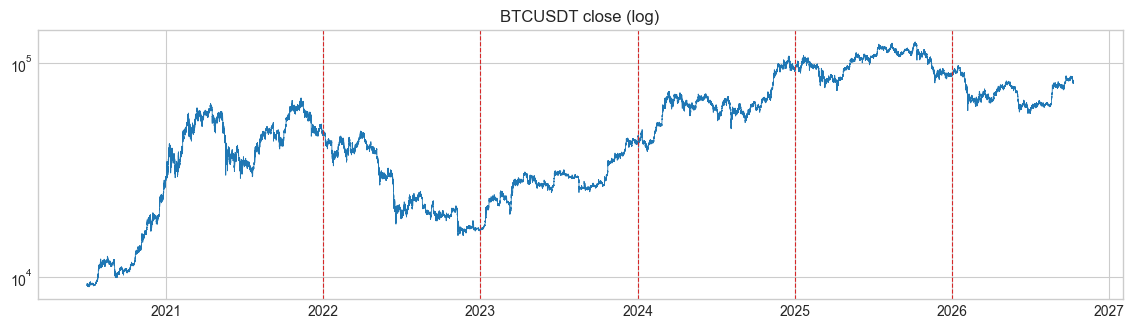

In [19]:
candles = mv2.load_candles(cfg.csv_path, cfg.bar_minutes)
delta = candles["timestamp"].diff()
display(pd.Series({
    "rows": len(candles),
    "start_utc": candles["timestamp"].min(),
    "end_utc": candles["timestamp"].max(),
    "irregular_steps": int((delta != pd.Timedelta(minutes=cfg.bar_minutes)).iloc[1:].sum()),
    "has_taker_volume": "taker_buy_volume" in candles.columns,
}).to_frame("value"))
display(candles.groupby(candles["timestamp"].dt.year).size().rename("candles").to_frame().T)
if "taker_buy_volume" not in candles.columns:
    print("⚠ Không có taker buy volume → thiếu feature order-flow tk_* (nhóm 'flow' chỉ còn vud_*). "
          "Nên bổ sung cột taker_buy_base_asset_volume khi thu thập dữ liệu.")

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(candles["timestamp"], candles["close"], lw=0.6)
ax.set(title="BTCUSDT close (log)", yscale="log")
for y in cfg.eval_years:
    ax.axvline(pd.Timestamp(f"{y}-01-01", tz="UTC"), color="tab:red", ls="--", lw=0.8)
plt.show()

## 2. Dựng dataset (feature nhân quả + nhãn)

In [20]:
t0 = time.time()
pivots = mv2.find_confirmed_pivots(candles, cfg.pivot_reversal)
ds = mv2.build_dataset(candles, pivots, cfg)
sample_time = pd.to_datetime(ds.timestamp_ns, utc=True)
display(pd.Series({
    "pivots": len(pivots),
    "samples": len(ds.decision_idx),
    "first_sample_utc": sample_time.min(),
    "last_sample_utc": sample_time.max(),
    "touch_features": len(ds.touch_names),
    "direction_features": len(ds.dir_names),
    "seconds": round(time.time() - t0, 1),
}).to_frame("value"))

grp = pd.Series(ds.feature_groups)
display(pd.concat({"touch": grp[list(ds.touch_names)].value_counts(),
                   "dir/ext/timeout": grp[list(ds.dir_names)].value_counts()}, axis=1).fillna(0).astype(int).T)

# kiểm tra feature
mv2.check_parity(ds.dir_names, ds.dir_parity)
probe = np.linspace(0, len(ds.x_dir) - 1, 5000).astype(int)
twice = mv2.mirror_matrix(ds.x_dir_mirror[probe], ds.dir_names, ds.dir_parity)
assert np.allclose(twice, ds.x_dir[probe], equal_nan=True), "mirror(mirror(x)) != x"
kinds = pd.Series({n: (p if isinstance(p, str) else "swap") for n, p in ds.dir_parity.items()}).value_counts()
print("Mirror parity OK:", kinds.to_dict())
nan_rate = pd.concat([pd.Series(np.isnan(ds.x_touch).mean(0), index=ds.touch_names),
                      pd.Series(np.isnan(ds.x_dir).mean(0), index=ds.dir_names)])
print("Feature có NaN > 1%:")
display(nan_rate[nan_rate > 0.01].sort_values(ascending=False).round(4).to_frame("nan_rate"))

,value
pivots,65700
samples,656543
first_sample_utc,2020-07-12 00:00:00+00:00
last_sample_utc,2026-10-08 15:50:00+00:00
touch_features,101
direction_features,114
seconds,32.3


,window,legs,context,relations,positions,levels,past,channel,dir:structure,dir:range,dir:move,dir:flow,dir:anchors,dir:regime,dir:candle,dir:funding,dir:vwap
touch,42,24,16,6,5,3,3,2,0,0,0,0,0,0,0,0,0
dir/ext/timeout,0,0,0,0,0,0,0,0,44,16,14,9,8,7,6,6,4


Mirror parity OK: {'odd': 61, 'swap': 28, 'even': 25}
Feature có NaN > 1%:


,nan_rate
c2_er,0.3558
c2_rv,0.3558
c2_dur,0.3558


## 3. Phân phối nhãn theo năm

- `touch_rate`: tỷ lệ chạm barrier. `up_share|touch`: trong các mẫu đã chạm, tỷ lệ chạm `+b` trước (≈ 0.5 nếu thị trường cân bằng).
- `ext_rate`: sau khi chạm `+b`/`−b` trước, tỷ lệ đi tiếp tới 2b trước khi quay về barrier đối diện.
- `r_*`: R trung bình của 4 mẫu lệnh nếu vào **mọi** mẫu (baseline không có model).
- `fee_R`: chi phí phí giao dịch tính theo đơn vị R (= phí / barrier) — edge của model phải vượt mức này.

,samples,touch_rate,barrier_pct,fee_R,r_long_1r,r_short_1r,r_long_2r,r_short_2r,up_share|touch,ext_rate,median_bars_to_touch
year,,,,,,,,,,,
2020,49824,0.4483,0.0117,0.0795,0.0581,-0.0583,0.0766,-0.0715,0.5355,0.2759,24.0
2021,105120,0.5369,0.0171,0.0528,-0.0120,0.0119,-0.0086,0.0126,0.4785,0.2520,23.0
2022,105120,0.4749,0.0126,0.0734,-0.0158,0.0146,-0.0249,0.0180,0.4794,0.2743,22.0
2023,105120,0.3916,0.0092,0.0946,0.0157,-0.0163,0.0209,-0.0250,0.5082,0.2999,22.0
2024,105408,0.4732,0.0108,0.0822,0.0177,-0.0178,0.0227,-0.0205,0.5001,0.2758,23.0
2025,105120,0.4145,0.0094,0.0936,0.0002,-0.0006,0.0003,0.0025,0.4860,0.2490,24.0
2026,80831,0.4336,0.0093,0.0937,-0.0123,0.0123,-0.0185,0.0051,0.4755,0.2345,23.0


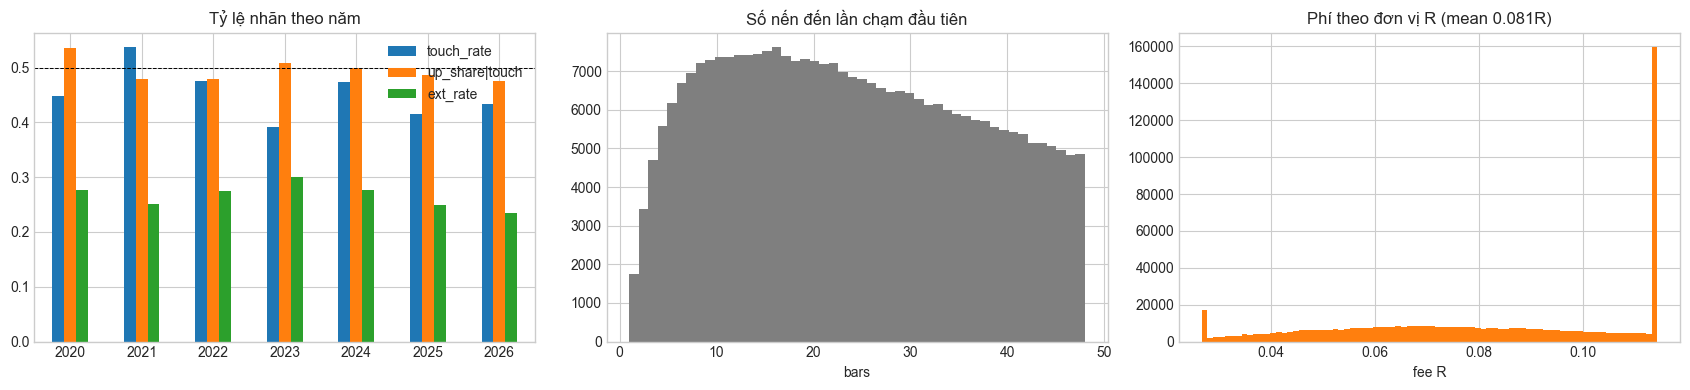

In [21]:
L = ds.labels
lab = pd.DataFrame({"year": sample_time.year, **{k: L[k] for k in ("y_touch", "y_up", "y_ext_long", "y_ext_short",
                                                                   "r_end", "t_first")},
                    **{f"r_{k}": L[f"r_{k}"] for k in mv2.TRADE_TEMPLATES},
                    "barrier_pct": ds.barrier_pct, "fee_R": cfg.fee_pct_roundtrip / ds.barrier_pct})
touched = lab[lab["y_up"] >= 0]
ext = pd.concat([lab.loc[lab["y_up"] == 1, ["year", "y_ext_long"]].rename(columns={"y_ext_long": "ext"}),
                 lab.loc[lab["y_up"] == 0, ["year", "y_ext_short"]].rename(columns={"y_ext_short": "ext"})])
year_stats = pd.concat([
    lab.groupby("year").agg(samples=("y_touch", "size"), touch_rate=("y_touch", "mean"),
                            barrier_pct=("barrier_pct", "mean"), fee_R=("fee_R", "mean"),
                            **{f"r_{k}": (f"r_{k}", "mean") for k in mv2.TRADE_TEMPLATES}),
    touched.groupby("year")["y_up"].mean().rename("up_share|touch"),
    ext.groupby("year")["ext"].mean().rename("ext_rate"),
    lab[lab["y_touch"] == 1].groupby("year")["t_first"].median().rename("median_bars_to_touch"),
], axis=1)
display(year_stats.round(4))

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
year_stats[["touch_rate", "up_share|touch", "ext_rate"]].plot(kind="bar", ax=axes[0], rot=0)
axes[0].axhline(0.5, color="k", lw=0.7, ls="--")
axes[0].set(title="Tỷ lệ nhãn theo năm", xlabel="")
axes[1].hist(lab.loc[lab["y_touch"] == 1, "t_first"], bins=cfg.barrier_horizon, color="tab:gray")
axes[1].set(title="Số nến đến lần chạm đầu tiên", xlabel="bars")
axes[2].hist(lab["fee_R"], bins=80, color="tab:orange")
axes[2].set(title=f"Phí theo đơn vị R (mean {lab['fee_R'].mean():.3f}R)", xlabel="fee R")
plt.tight_layout()
plt.show()

## 4. Chia fold walk-forward

In [22]:
def ts_range(ids):
    t = pd.to_datetime(ds.timestamp_ns[ids], utc=True)
    return f"{t.min():%Y-%m-%d} → {t.max():%Y-%m-%d}"

folds, rows = {}, []
for year in cfg.eval_years:
    tr, va, te = mv2.fold_ids(ds, year)
    es, cal = mv2.split_validation(ds, va, cfg.val_es_frac)
    folds[year] = (tr, va, te)
    rows.append({"eval_year": year, "train": len(tr), "val_es": len(es), "val_cal": len(cal), "test": len(te),
                 "train_range": ts_range(tr), "es_range": ts_range(es), "cal_range": ts_range(cal),
                 "test_range": ts_range(te)})
display(pd.DataFrame(rows).set_index("eval_year"))

,train,val_es,val_cal,test,train_range,es_range,cal_range,test_range
eval_year,,,,,,,,
2022,49776,62995,42029,105072,2020-07-12 → 2020-12-31,2021-01-01 → 2021-08-07,2021-08-07 → 2021-12-31,2022-01-01 → 2022-12-31
2023,154896,62995,42029,105072,2020-07-12 → 2021-12-31,2022-01-01 → 2022-08-07,2022-08-07 → 2022-12-31,2023-01-01 → 2023-12-31
2024,260016,62995,42029,105360,2020-07-12 → 2022-12-31,2023-01-01 → 2023-08-07,2023-08-07 → 2023-12-31,2024-01-01 → 2024-12-31
2025,365136,63168,42144,105072,2020-07-12 → 2023-12-31,2024-01-01 → 2024-08-07,2024-08-07 → 2024-12-31,2025-01-01 → 2025-12-31
2026,470544,62995,42029,80831,2020-07-12 → 2024-12-31,2025-01-01 → 2025-08-07,2025-08-07 → 2025-12-31,2026-01-01 → 2026-10-08


## 5. Huấn luyện từng năm

Mỗi fold train lại 4 model. Dự báo test được lưu vào `predictions_<year>.npz` (gồm tất cả signal và nhãn), model năm cuối được export thành `models_final.joblib` (dùng được trực tiếp với `mv2.predict_frame`).

In [23]:
reports, fitted_by_year = [], {}
t_all = time.time()
for year, (tr, va, te) in folds.items():
    t0 = time.time()
    fitted = mv2.fit_models(ds, tr, va, cfg)
    rep = mv2.evaluate_fold(str(year), fitted, tr, te, ds, cfg, OUT)
    reports.append(rep)
    fitted_by_year[year] = fitted
    print(mv2.summary_line(rep), f"| {time.time() - t0:.0f}s", flush=True)
print(f"Tổng thời gian: {(time.time() - t_all) / 60:.1f} phút")

last = cfg.eval_years[-1]
mv2.export_bundle(OUT / "models_final.joblib", fitted_by_year[last]["models"], ds, cfg)
result = {"candles": len(candles), "pivots": len(pivots), "samples": len(ds.decision_idx),
          "touch_features": len(ds.touch_names), "direction_features": len(ds.dir_names),
          "has_taker_volume": "taker_buy_volume" in candles.columns,
          "folds": reports, "final_fold": str(last), "output_dir": str(OUT)}
(OUT / "metadata.json").write_text(json.dumps({"strategy": mv2.STRATEGY, "config": asdict(cfg), **result},
                                              indent=2, default=mv2._json_default), encoding="utf-8")
print("Đã lưu:", OUT)

  2022 | touch AUC 0.635 | dir AUC 0.562 [+0.538,+0.587] | ext AUC 0.572 | IC1r -0.013 [-0.043,+0.026] | top5% best: net -0.129R x146 indep | 122s
  2023 | touch AUC 0.674 | dir AUC 0.596 [+0.566,+0.622] | ext AUC 0.602 | IC1r +0.014 [-0.014,+0.049] | top5% best: net -0.059R x235 indep | 145s
  2024 | touch AUC 0.732 | dir AUC 0.588 [+0.566,+0.612] | ext AUC 0.582 | IC1r +0.078 [+0.042,+0.110] | top5% best: net +0.024R x532 indep | 172s
  2025 | touch AUC 0.736 | dir AUC 0.546 [+0.521,+0.573] | ext AUC 0.605 | IC1r +0.008 [-0.022,+0.039] | top5% best: net -0.094R x360 indep | 168s
  2026 | touch AUC 0.745 | dir AUC 0.573 [+0.542,+0.604] | ext AUC 0.623 | IC1r +0.061 [+0.030,+0.094] | top5% best: net +0.097R x210 indep | 138s
Tổng thời gian: 12.4 phút
Đã lưu: C:\Users\thanh\BTC_PIPELINE\artifacts\5m_xgboost_signal_v2


## 6. Bảng tổng hợp

Ý nghĩa và ngưỡng tham khảo:

- `dir_auc`: năng lực dự báo **hướng** thật sự (chỉ trên mẫu đã chạm). 0.5 = không có tín hiệu. Quan trọng nhất là cận dưới của CI > 0.5.
- `ext_auc`: phân biệt được các move sẽ chạy dài hay không.
- `timeout_ic`: drift khi giá không chạm barrier (Spearman).
- `ic1r`: Spearman(e_long_1r − e_short_1r, r_long_1r − r_short_1r) — tổng hợp của cả hệ thống cho lệnh 1R.
- `ic_edge_best`: edge kỳ vọng lớn hơn có đi kèm R thực hiện lớn hơn không.

In [24]:
def ci_str(c):
    return f"[{c[0]:.3f}, {c[1]:.3f}]"

def fold_row(rep, stage):
    m = rep[stage]
    er = m["expected_R"]
    return {
        "fold": rep["fold"], "stage": "val(cal)" if stage.startswith("validation") else "test",
        "touch_auc": m["touch"]["auc"], "touch_skill": m["touch"]["log_loss_skill"],
        "dir_auc": m["direction"]["auc"], "dir_auc_lo": m["direction"]["auc_ci"][0],
        "dir_auc_hi": m["direction"]["auc_ci"][1], "dir_skill": m["direction"]["log_loss_skill"],
        "ext_auc": m["extension"]["auc"], "ext_skill": m["extension"]["log_loss_skill"],
        "timeout_ic": m["timeout"]["ic"],
        "ic1r": er["1r"]["ic_spread"], "ic1r_lo": er["1r"]["ic_spread_ci"][0], "ic1r_hi": er["1r"]["ic_spread_ci"][1],
        "ic2r": er["2r"]["ic_spread"], "ic_edge_best": er["best"]["ic_edge"], "fee_R": m["mean_fee_R"],
    }

summary = pd.DataFrame([fold_row(r, s) for r in reports for s in ("validation_metrics", "heldout_metrics")])
summary = summary.set_index(["fold", "stage"]).sort_index()
display(summary.round(4))
test_only = summary.xs("test", level="stage")
display(test_only.mean().to_frame("mean_test").T.round(4))

meta = pd.DataFrame([{"fold": r["fold"], **{f"rounds_{k}": v for k, v in r["best_rounds"].items()},
                      **r["temperatures"], **r["constants"]} for r in reports]).set_index("fold")
display(meta.round(4))
print("Lưu ý: rounds_dir / rounds_timeout rất nhỏ (vài chục) nghĩa là early stopping thấy rất ít tín hiệu để học.")

touch_auc  touch_skill  dir_auc  dir_auc_lo  dir_auc_hi  dir_skill  ext_auc  ext_skill  timeout_ic    ic1r  ic1r_lo  ic1r_hi    ic2r  ic_edge_best   fee_R
fold stage                                                                                                                                                               
2022 test         0.6352       0.0398   0.5624      0.5375      0.5874     0.0085   0.5721     0.0042      0.2313 -0.0131  -0.0429   0.0255 -0.0018       -0.0190  0.0733
     val(cal)     0.5971       0.0320   0.5492      0.5043      0.5850     0.0052   0.5397    -0.0109      0.2165  0.0213  -0.0183   0.0633  0.0195       -0.0039  0.0624
2023 test         0.6739       0.0968   0.5961      0.5661      0.6223     0.0188   0.6018     0.0230      0.2729  0.0135  -0.0139   0.0489  0.0155        0.0051  0.0946
     val(cal)     0.6603       0.0704   0.5713      0.5243      0.6088     0.0112   0.5744     0.0042      0.2348 -0.0175  -0.0693   0.0308  0.0062       -0.0182  0.0877
2024 test         0.7317       0.1298   0.5882      0.5656      0.6117     0.0164   0.5816     0.0128      0.2340  0.0781   0.0420   0.1104  0.0843        0.0216  0.0822
     val(cal)     0.7564       0.1854   0.5830      0.5413      0.6318     0.0157   0.6167     0.0352      0.2812  0.0265  -0.0239   0.0840  0.0293        0.0016  0.0985
2025 test         0.7364       0.1325   0.5465      0.5210      0.5735    -0.0000   0.6048     0.0214      0.1704  0.0081  -0.0218   0.0388  0.0042       -0.0199  0.0936
     val(cal)     0.7681       0.1712   0.5826      0.5407      0.6157     0.0152   0.5945     0.0195      0.2176  0.0575   0.0176   0.0983  0.0631       -0.0027  0.0836
2026 test         0.7449       0.1477   0.5734      0.5423      0.6039     0.0101   0.6228     0.0328      0.1535  0.0606   0.0305   0.0935  0.0633       -0.0011  0.0937
     val(cal)     0.7498       0.1607   0.5433      0.4938      0.5946     0.0043   0.6022     0.0223      0.1955  0.0305  -0.0122   0.0819  0.0173       -0.0044  0.0950

,touch_auc,touch_skill,dir_auc,dir_auc_lo,dir_auc_hi,dir_skill,ext_auc,ext_skill,timeout_ic,ic1r,ic1r_lo,ic1r_hi,ic2r,ic_edge_best,fee_R
mean_test,0.7044,0.1093,0.5733,0.5465,0.5997,0.0108,0.5966,0.0188,0.2124,0.0295,-0.0012,0.0634,0.0331,-0.0027,0.0875


,rounds_touch,rounds_dir,rounds_ext,rounds_timeout,T_touch,T_dir,T_ext,tie_rate,nonext_R,ext_mult
fold,,,,,,,,,,
2022,124,60,89,144,1.5467,1.2354,1.1463,0.0002,0.6356,2.0
2023,276,71,329,601,1.0374,0.6619,0.9388,0.0001,0.6627,2.0
2024,384,964,411,518,0.7883,1.2987,1.1180,0.0006,0.6409,2.0
2025,342,131,224,491,0.7133,0.8286,0.9625,0.0006,0.6219,2.0
2026,321,46,429,99,0.8710,1.0636,0.9868,0.0005,0.6227,2.0


Lưu ý: rounds_dir / rounds_timeout rất nhỏ (vài chục) nghĩa là early stopping thấy rất ít tín hiệu để học.


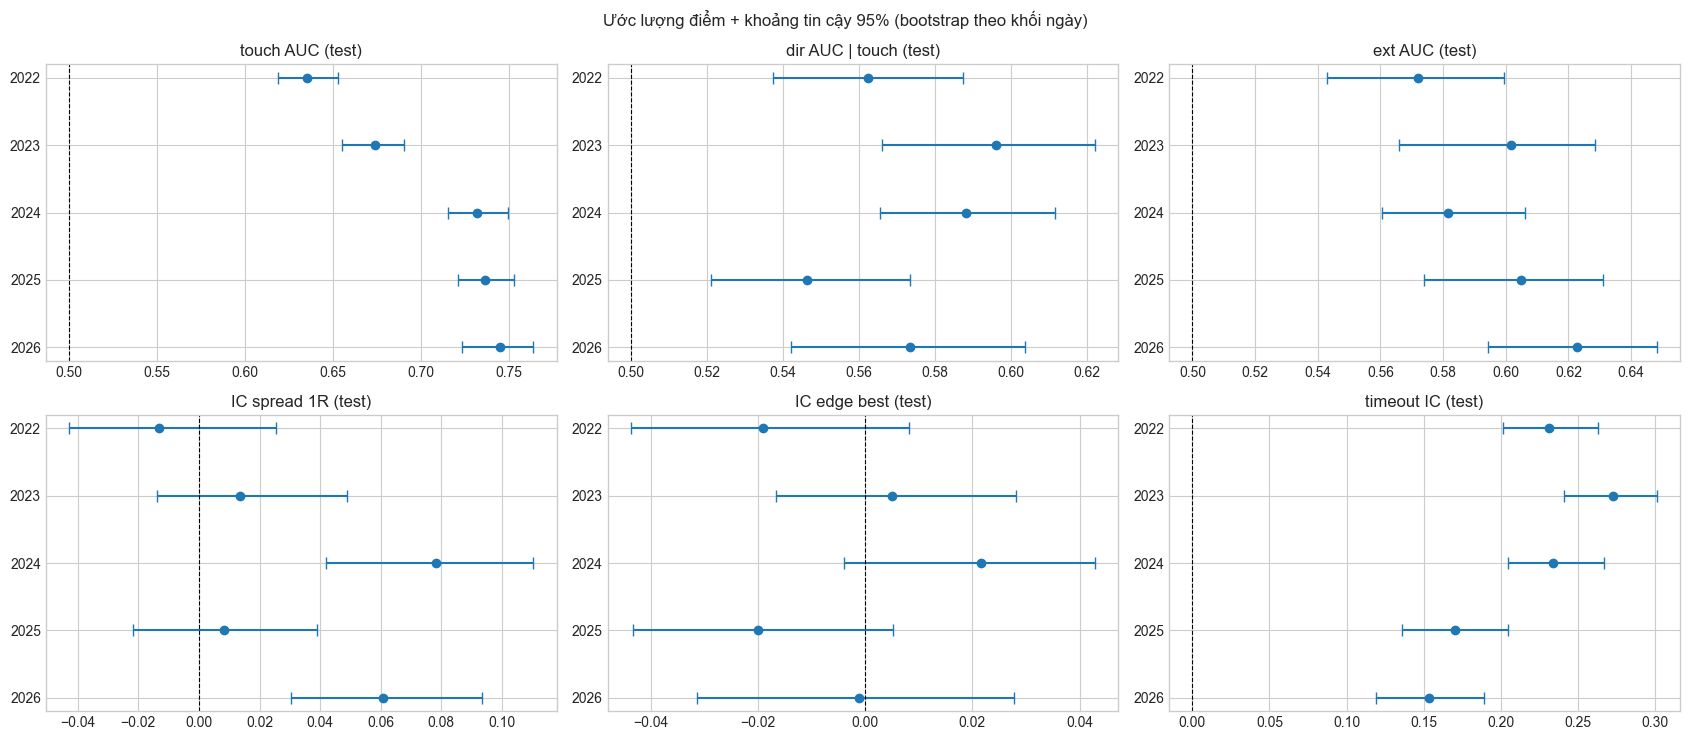

In [25]:
def forest(ax, rows, key, title, ref):
    y = np.arange(len(rows))
    vals = [r[0] for r in rows]
    lo = [r[0] - r[1][0] for r in rows]
    hi = [r[1][1] - r[0] for r in rows]
    ax.errorbar(vals, y, xerr=[lo, hi], fmt="o", color="tab:blue", capsize=4)
    ax.axvline(ref, color="k", ls="--", lw=0.8)
    ax.set_yticks(y, [r[2] for r in rows])
    ax.set(title=title)
    ax.invert_yaxis()

h = lambda r: r["heldout_metrics"]
panels = [
    ("touch AUC (test)", 0.5, [(h(r)["touch"]["auc"], h(r)["touch"]["auc_ci"], r["fold"]) for r in reports]),
    ("dir AUC | touch (test)", 0.5, [(h(r)["direction"]["auc"], h(r)["direction"]["auc_ci"], r["fold"]) for r in reports]),
    ("ext AUC (test)", 0.5, [(h(r)["extension"]["auc"], h(r)["extension"]["auc_ci"], r["fold"]) for r in reports]),
    ("IC spread 1R (test)", 0.0, [(h(r)["expected_R"]["1r"]["ic_spread"], h(r)["expected_R"]["1r"]["ic_spread_ci"], r["fold"]) for r in reports]),
    ("IC edge best (test)", 0.0, [(h(r)["expected_R"]["best"]["ic_edge"], h(r)["expected_R"]["best"]["ic_edge_ci"], r["fold"]) for r in reports]),
    ("timeout IC (test)", 0.0, [(h(r)["timeout"]["ic"], h(r)["timeout"]["ic_ci"], r["fold"]) for r in reports]),
]
fig, axes = plt.subplots(2, 3, figsize=(17, 2.0 + 1.1 * len(reports)))
for ax, (title, ref, rows) in zip(axes.ravel(), panels):
    forest(ax, rows, title, title, ref)
plt.suptitle("Ước lượng điểm + khoảng tin cậy 95% (bootstrap theo khối ngày)")
plt.tight_layout()
plt.show()

## 7. Touch model

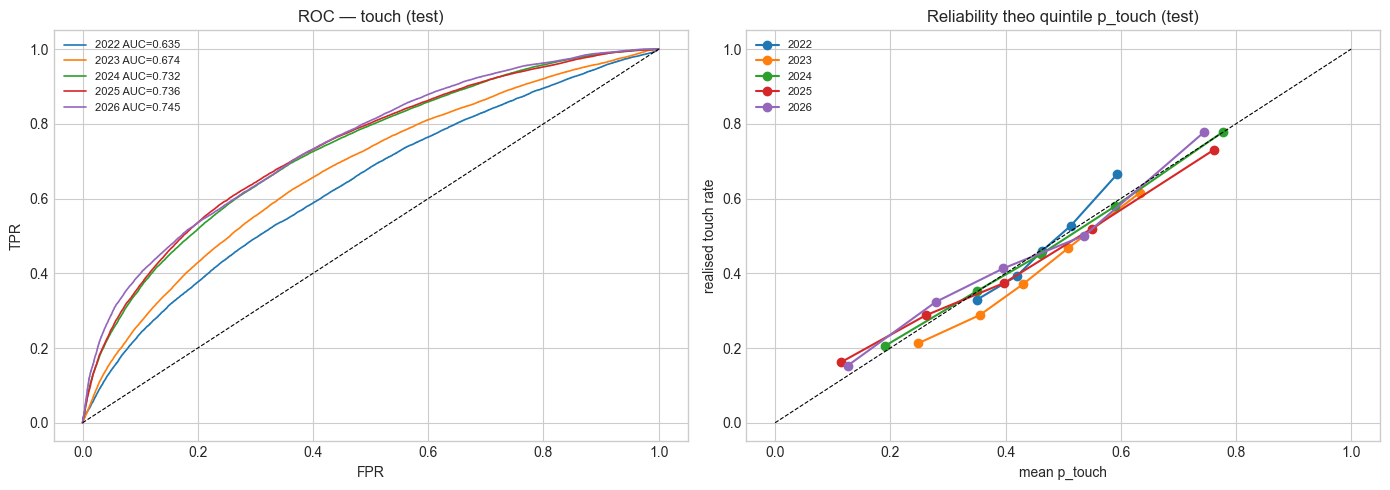

In [26]:
preds = {}
for year in folds:
    z = np.load(OUT / f"predictions_{year}.npz")
    preds[year] = {k: z[k] for k in z.files}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for year, p in preds.items():
    fpr, tpr, _ = roc_curve(p["label_y_touch"], p["p_touch"])
    rep = next(r for r in reports if r["fold"] == str(year))
    axes[0].plot(fpr, tpr, lw=1.2, label=f"{year} AUC={h(rep)['touch']['auc']:.3f}")
    rel = pd.DataFrame(h(rep)["touch"]["reliability"])
    axes[1].plot(rel["mean_pred"], rel["mean_realised"], "o-", label=str(year))
for ax in axes:
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.legend(fontsize=8)
axes[0].set(title="ROC — touch (test)", xlabel="FPR", ylabel="TPR")
axes[1].set(title="Reliability theo quintile p_touch (test)", xlabel="mean p_touch", ylabel="realised touch rate")
plt.tight_layout()
plt.show()

## 8. Direction | touch và Extension

Reliability của `p_up_touch` (decile) — nếu model có tín hiệu, đường phải dốc lên và nằm gần đường chéo. Bảng dưới: AUC của hướng theo nhóm `p_touch` (hướng có rõ hơn khi model dự báo giá sẽ chạy không?).

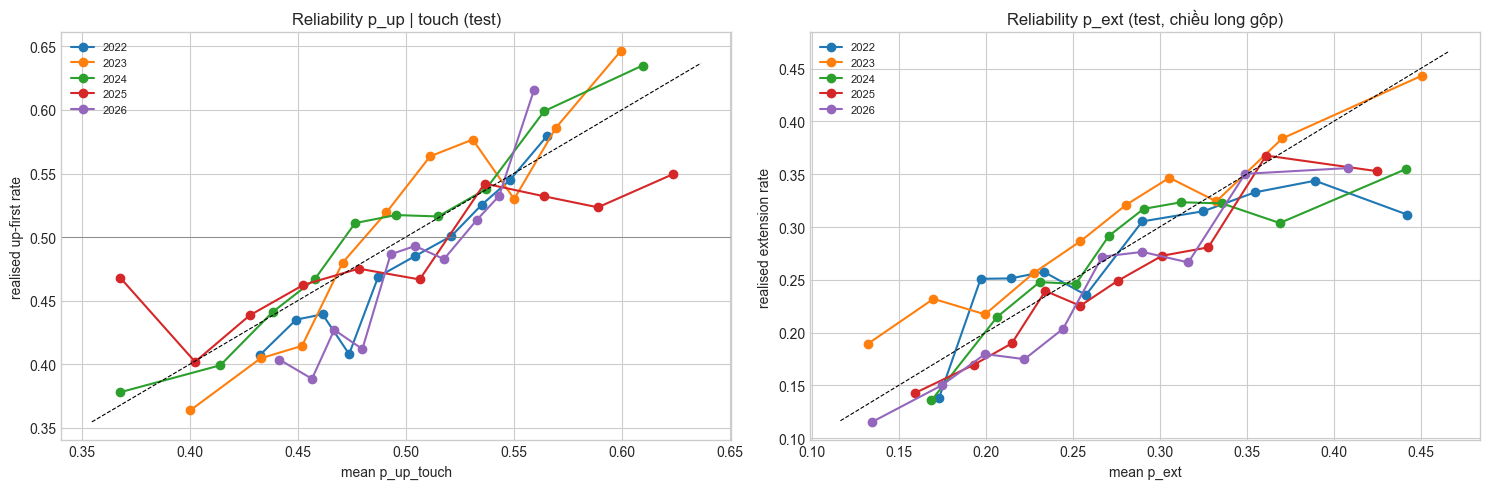

Direction AUC theo quintile p_touch (T5 = model chắc chắn giá sẽ chạy nhất):


p_touch_q,T1,T2,T3,T4,T5
year,,,,,
2022,0.5947,0.5918,0.5663,0.5584,0.5003
2023,0.6382,0.6284,0.5757,0.5556,0.5540
2024,0.6073,0.6165,0.5779,0.6055,0.5252
2025,0.5571,0.5675,0.5539,0.5385,0.5166
2026,0.6429,0.5383,0.5555,0.5458,0.5817


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for r in reports:
    rel = pd.DataFrame(h(r)["direction"]["reliability"])
    axes[0].plot(rel["mean_pred"], rel["mean_realised"], "o-", label=r["fold"])
lo, hi = axes[0].get_xlim()
axes[0].plot([lo, hi], [lo, hi], "k--", lw=0.8)
axes[0].axhline(0.5, color="gray", lw=0.6)
axes[0].set(title="Reliability p_up | touch (test)", xlabel="mean p_up_touch", ylabel="realised up-first rate")
axes[0].legend(fontsize=8)

rows = []
for year, p in preds.items():
    up, dn = p["label_y_up"] == 1, p["label_y_up"] == 0
    y_e = np.concatenate([p["label_y_ext_long"][up], p["label_y_ext_short"][dn]])
    p_e = np.concatenate([p["p_ext_long"][up], p["p_ext_short"][dn]])
    q = pd.qcut(p_e, 10, labels=False, duplicates="drop")
    g = pd.DataFrame({"q": q, "p": p_e, "y": y_e}).groupby("q").mean()
    axes[1].plot(g["p"], g["y"], "o-", label=str(year))
    m = p["label_y_up"] >= 0
    tq = pd.qcut(p["p_touch"][m], 5, labels=[f"T{i}" for i in range(1, 6)])
    for t in tq.categories:
        k = np.asarray(tq == t)
        rows.append({"year": year, "p_touch_q": t,
                     "dir_auc": mv2.safe_auc(p["label_y_up"][m][k], p["p_up_touch"][m][k])})
lo, hi = axes[1].get_xlim()
axes[1].plot([lo, hi], [lo, hi], "k--", lw=0.8)
axes[1].set(title="Reliability p_ext (test, chiều long gộp)", xlabel="mean p_ext", ylabel="realised extension rate")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print("Direction AUC theo quintile p_touch (T5 = model chắc chắn giá sẽ chạy nhất):")
display(pd.DataFrame(rows).pivot(index="year", columns="p_touch_q", values="dir_auc").round(4))

## 9. Calibration của R kỳ vọng

Mỗi điểm là một decile của `e_*`: trục x = R kỳ vọng model dự báo, trục y = R thực hiện trung bình. Đây là kiểm tra quan trọng nhất trước khi dùng `e_*` để thiết kế lệnh — nếu các điểm nằm dưới đường chéo ở phía phải thì model lạc quan quá mức với các tín hiệu mạnh.

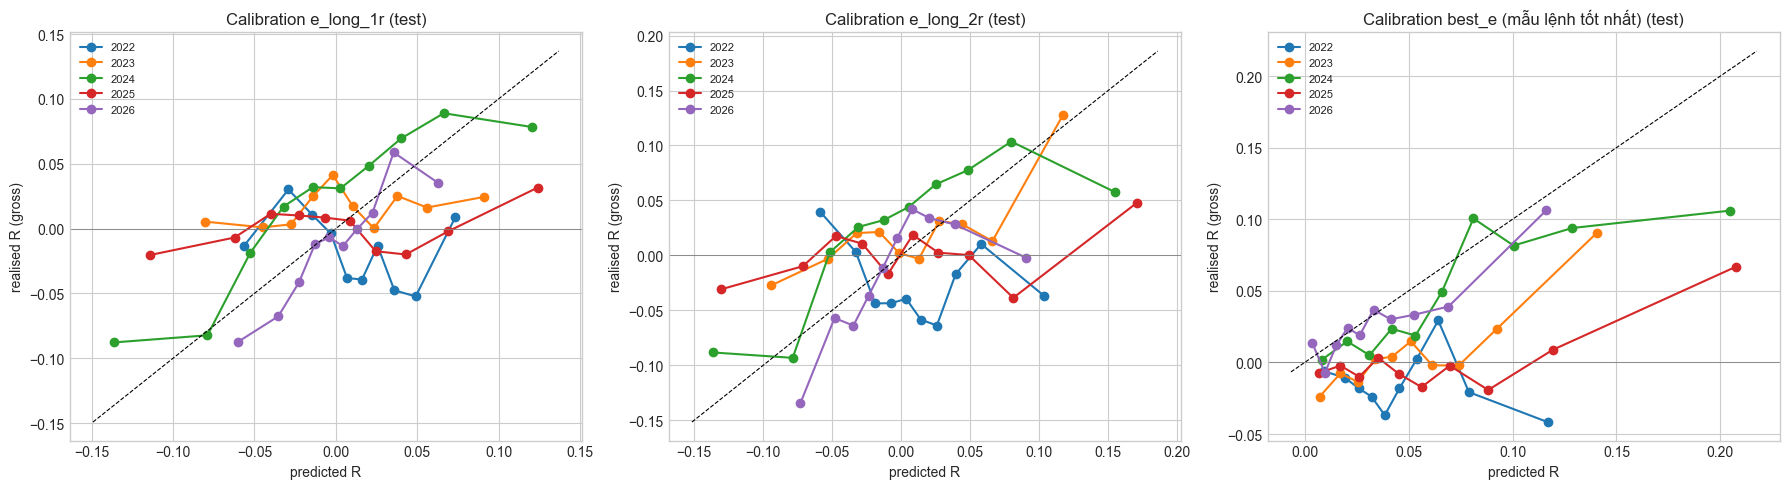

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for r in reports:
    er = h(r)["expected_R"]
    c1 = pd.DataFrame(er["1r"]["calibration"]["long_1r"])
    c2 = pd.DataFrame(er["2r"]["calibration"]["long_2r"])
    cb = pd.DataFrame(er["best"]["edge_calibration"])
    axes[0].plot(c1["mean_pred"], c1["mean_realised"], "o-", label=r["fold"])
    axes[1].plot(c2["mean_pred"], c2["mean_realised"], "o-", label=r["fold"])
    axes[2].plot(cb["mean_pred"], cb["mean_realised"], "o-", label=r["fold"])
for ax, t in zip(axes, ("e_long_1r", "e_long_2r", "best_e (mẫu lệnh tốt nhất)")):
    lo, hi = ax.get_xlim()
    ax.plot([lo, hi], [lo, hi], "k--", lw=0.8)
    ax.axhline(0, color="gray", lw=0.6)
    ax.set(title=f"Calibration {t} (test)", xlabel="predicted R", ylabel="realised R (gross)")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 10. Chọn tín hiệu với ngưỡng từ calibration (sau phí)

Với mỗi bộ mẫu lệnh (`1r`, `2r`, `best`) và mỗi mức top-q%, ngưỡng edge được lấy từ phần calibration của năm validation rồi áp lên năm test.

- `mean_net_R`: R trung bình sau phí trên mọi mẫu được chọn (có chồng lấn).
- `independent_signals`, `independent_mean_net_R`: chỉ giữ tín hiệu không chồng lấn (sau mỗi tín hiệu bỏ qua H nến) — gần với số lệnh thật.

Gộp các năm test:


C:\Users\thanh\AppData\Local\Temp\ipykernel_24996\662514453.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pooled = sel.groupby(["rr", "top_fraction"]).apply(lambda g: pd.Series({


years_net_positive  independent_signals  independent_total_net_R  independent_mean_net_R
rr   top_fraction                                                                                          
1r   0.02                         0.0               1063.0                 -45.9550                 -0.0432
     0.05                         0.0               2053.0                -100.4275                 -0.0489
     0.10                         0.0               3367.0                -149.9446                 -0.0445
     0.20                         1.0               5241.0                -272.9876                 -0.0521
     0.50                         0.0               8955.0                -643.9842                 -0.0719
     1.00                         0.0              10446.0                -725.5437                 -0.0695
2r   0.02                         2.0                708.0                 -41.5512                 -0.0587
     0.05                         2.0               1460.0                 -49.8195                 -0.0341
     0.10                         1.0               2438.0                 -87.4614                 -0.0359
     0.20                         0.0               4390.0                -223.3256                 -0.0509
     0.50                         0.0               8434.0                -443.3187                 -0.0526
     1.00                         0.0              10446.0                -653.9479                 -0.0626
best 0.02                         2.0                711.0                 -40.0898                 -0.0564
     0.05                         2.0               1483.0                 -33.5896                 -0.0226
     0.10                         1.0               2554.0                 -73.9584                 -0.0290
     0.20                         1.0               4604.0                -241.6364                 -0.0525
     0.50                         0.0               8576.0                -591.6378                 -0.0690
     1.00                         0.0              10446.0                -667.5366                 -0.0639

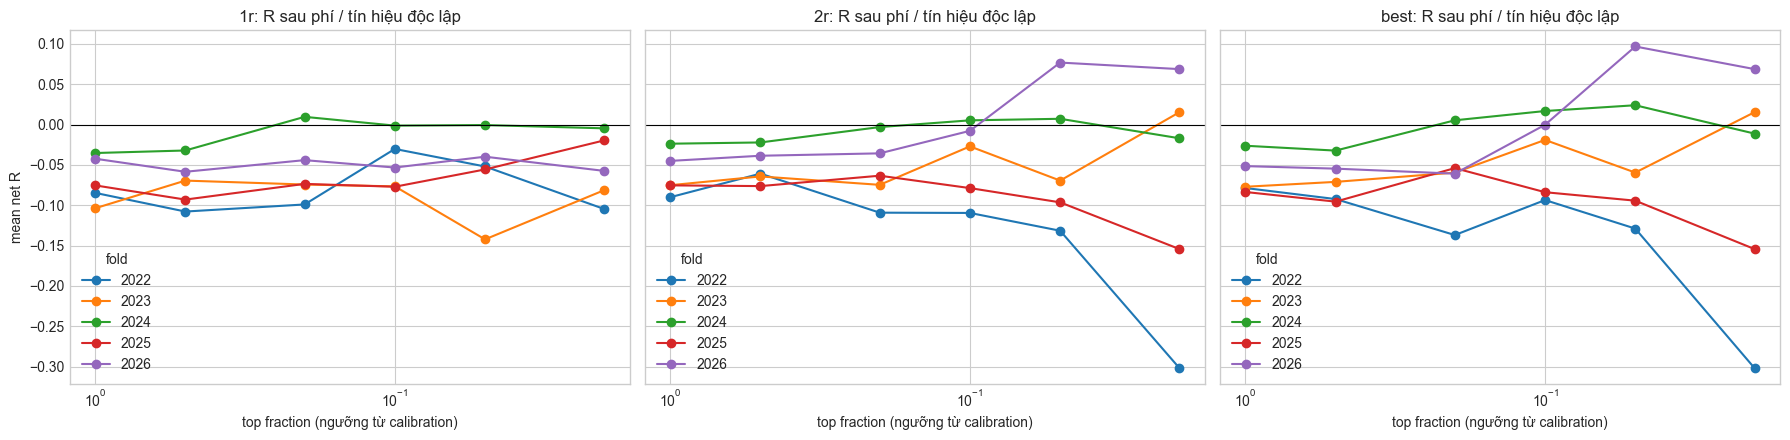

Chi tiết theo năm (best):


selected_share  samples  mean_pred_R  mean_R  mean_net_R  hit_rate  long_share  independent_signals  independent_mean_net_R  independent_total_net_R
fold top_fraction                                                                                                                                                      
2022 1.00                  1.0000   105072       0.0485 -0.0145     -0.0878    0.4794      0.5859                 2189                 -0.0786                -171.9958
     0.50                  0.4271    44873       0.0766 -0.0074     -0.0797    0.4776      0.6277                 1647                 -0.0923                -152.0154
     0.20                  0.1415    14871       0.1074 -0.0372     -0.1084    0.4437      0.6461                  743                 -0.1369                -101.7268
     0.10                  0.0581     6107       0.1317 -0.0877     -0.1575    0.4102      0.6743                  321                 -0.0935                 -30.0221
     0.05                  0.0258     2715       0.1530 -0.1504     -0.2166    0.3731      0.7263                  146                 -0.1289                 -18.8194
     0.02                  0.0097     1020       0.1744 -0.0873     -0.1498    0.4078      0.8284                   59                 -0.3019                 -17.8137
2023 1.00                  1.0000   105071       0.0545  0.0085     -0.0860    0.4920      0.5334                 2189                 -0.0771                -168.6682
     0.50                  0.3931    41301       0.0927  0.0278     -0.0661    0.4904      0.5497                 1635                 -0.0710                -116.0532
     0.20                  0.1282    13466       0.1319  0.0781     -0.0140    0.4938      0.5643                  776                 -0.0595                 -46.1596
     0.10                  0.0606     6369       0.1578  0.1074      0.0164    0.5020      0.5455                  415                 -0.0190                  -7.8711
     0.05                  0.0293     3078       0.1831  0.0909      0.0026    0.4773      0.5253                  235                 -0.0594                 -13.9684
     0.02                  0.0112     1172       0.2175  0.1173      0.0329    0.4514      0.5503                   98                  0.0154                   1.5111
2024 1.00                  1.0000   105360       0.0736  0.0495     -0.0327    0.5160      0.4729                 2195                 -0.0262                 -57.4457
     0.50                  0.5641    59431       0.1093  0.0787     -0.0052    0.5233      0.4621                 1966                 -0.0322                 -63.3028
     0.20                  0.2603    27426       0.1523  0.0936      0.0093    0.5197      0.4569                 1309                  0.0054                   7.0188
     0.10                  0.1380    14544       0.1869  0.1075      0.0227    0.5111      0.4488                  841                  0.0169                  14.1996
     0.05                  0.0739     7785       0.2213  0.1152      0.0293    0.4904      0.4275                  532                  0.0240                  12.7928
     0.02                  0.0280     2952       0.2724  0.0875      0.0015    0.4566      0.3825                  261                 -0.0111                  -2.9020
2025 1.00                  1.0000   105072       0.0672  0.0012     -0.0923    0.4869      0.5161                 2189                 -0.0835                -182.7907
     0.50                  0.5049    53054       0.1076  0.0069     -0.0877    0.4812      0.5329                 1922                 -0.0955                -183.5403
     0.20                  0.2002    21033       0.1633  0.0374     -0.0584    0.4725      0.5704                 1044                 -0.0539                 -56.2743
     0.10                  0.1043    10957       0.2047  0.0642     -0.0330    0.4663      0.5654                  599                 -0.0838             

In [29]:
sel_rows = []
for r in reports:
    for rr in ("1r", "2r", "best"):
        for row in h(r)["expected_R"][rr]["top_cal_threshold"]:
            sel_rows.append({"fold": r["fold"], "rr": rr, **row})
sel = pd.DataFrame(sel_rows)
cols = ["selected_share", "samples", "mean_pred_R", "mean_R", "mean_net_R", "hit_rate", "long_share",
        "independent_signals", "independent_mean_net_R", "independent_total_net_R"]
pooled = sel.groupby(["rr", "top_fraction"]).apply(lambda g: pd.Series({
    "years_net_positive": int((g["independent_mean_net_R"] > 0).sum()),
    "independent_signals": int(g["independent_signals"].sum()),
    "independent_total_net_R": float(g["independent_total_net_R"].sum()),
    "independent_mean_net_R": float(g["independent_total_net_R"].sum() / max(g["independent_signals"].sum(), 1)),
}))
print("Gộp các năm test:")
display(pooled.round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)
for ax, rr in zip(axes, ("1r", "2r", "best")):
    piv = sel[sel["rr"] == rr].pivot(index="top_fraction", columns="fold", values="independent_mean_net_R")
    piv.sort_index(ascending=False).plot(ax=ax, marker="o", logx=True)
    ax.invert_xaxis()
    ax.axhline(0, color="k", lw=0.8)
    ax.set(title=f"{rr}: R sau phí / tín hiệu độc lập", xlabel="top fraction (ngưỡng từ calibration)")
axes[0].set_ylabel("mean net R")
plt.tight_layout()
plt.show()

print("Chi tiết theo năm (best):")
display(sel[sel["rr"] == "best"].set_index(["fold", "top_fraction"])[cols].round(4))

## 11. Ổn định theo tháng và đường R cộng dồn (chẩn đoán, không phải backtest)

Chọn bộ mẫu lệnh và mức top-q ở cell dưới. Đường cộng dồn chỉ dùng tín hiệu **không chồng lấn**, ngưỡng từ calibration, đã trừ phí. Chưa có trượt giá, funding, giới hạn vốn — phần đó thuộc bước backtest.

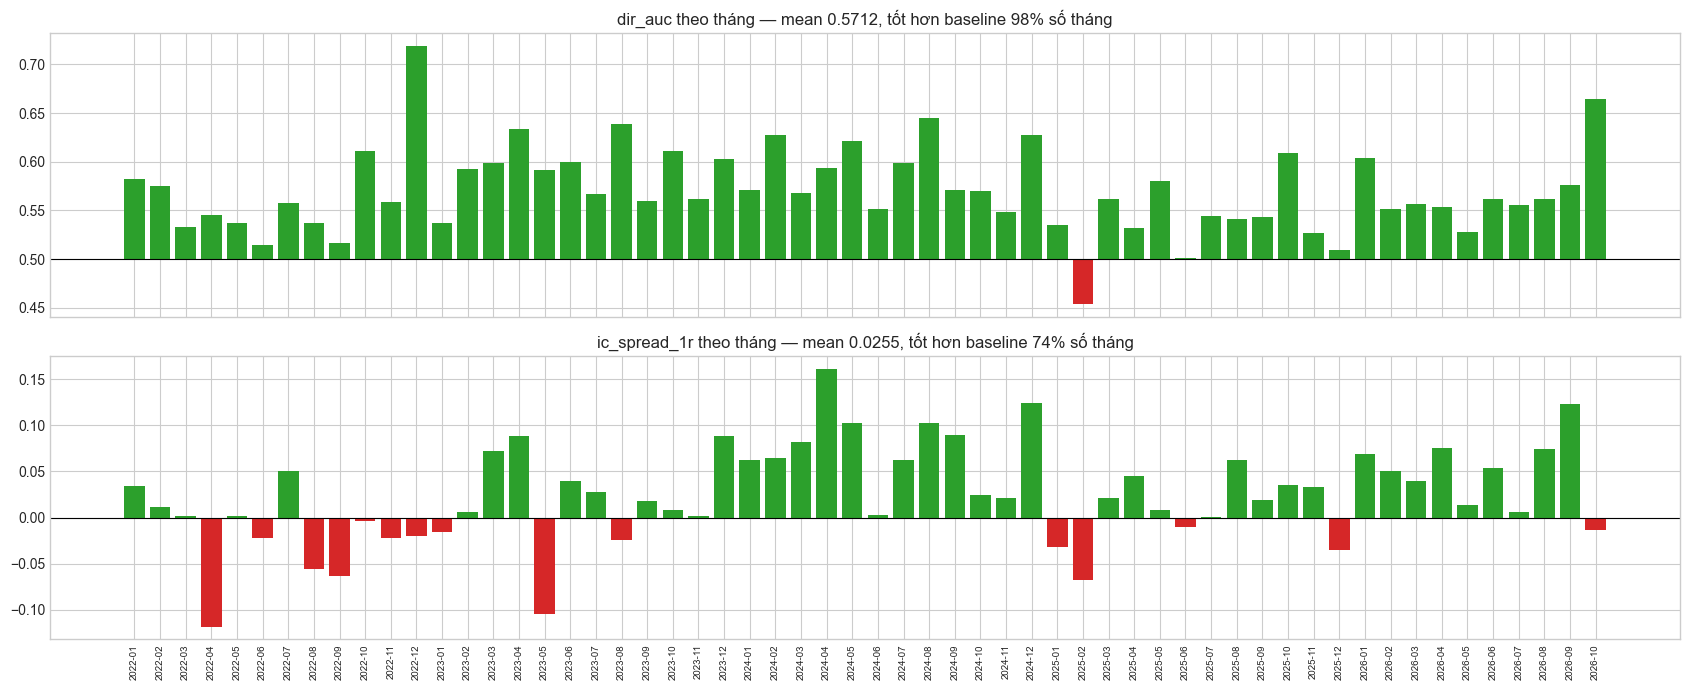

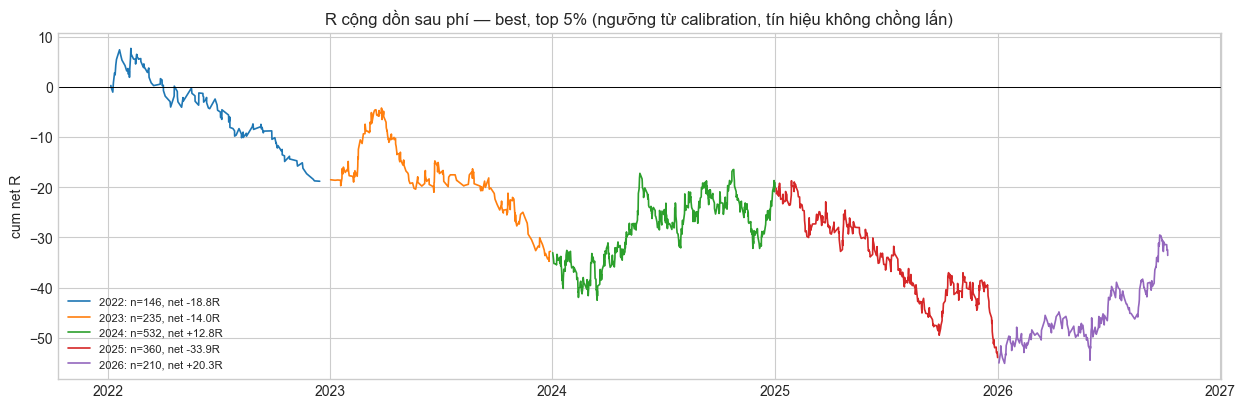

,signals,net_R,mean_net_R,hit_rate,max_drawdown_R
year,,,,,
2022,146,-18.8194,-0.1289,0.3699,26.4649
2023,235,-13.9684,-0.0594,0.4298,30.5437
2024,532,12.7928,0.0240,0.4605,15.7258
2025,360,-33.9431,-0.0943,0.3944,35.2146
2026,210,20.3484,0.0969,0.4857,9.6283


In [30]:
SEL_RR, SEL_Q = "best", 0.05

monthly = pd.concat([pd.DataFrame(r["monthly"]) for r in reports]).set_index("month")
fig, axes = plt.subplots(2, 1, figsize=(17, 7), sharex=True)
for ax, col, base in ((axes[0], "dir_auc", 0.5), (axes[1], "ic_spread_1r", 0.0)):
    vals = monthly[col]
    ax.bar(vals.index, vals - base, bottom=base, color=np.where(vals > base, "tab:green", "tab:red"))
    ax.axhline(base, color="k", lw=0.8)
    ax.set(title=f"{col} theo tháng — mean {vals.mean():.4f}, tốt hơn baseline {np.mean(vals > base):.0%} số tháng")
axes[1].tick_params(axis="x", rotation=90, labelsize=7)
plt.tight_layout()
plt.show()

def template_choice(p, rr):
    names = mv2.RR_SETS[rr]
    e = np.column_stack([p[f"e_{k}"] for k in names])
    r = np.column_stack([p[f"label_r_{k}"] for k in names])
    k = e.argmax(axis=1)
    row = np.arange(len(k))
    return e[row, k], r[row, k]

fig, ax = plt.subplots(figsize=(15, 4.5))
offset, stats = 0.0, []
for r in reports:
    year = int(r["fold"])
    p = preds[year]
    thr = r["edge_thresholds_from_calibration"][SEL_RR][SEL_Q]
    edge, real = template_choice(p, SEL_RR)
    net = real - cfg.fee_pct_roundtrip / p["barrier_pct"]
    pick = np.where(edge >= thr)[0]
    pick = pick[mv2.non_overlapping(p["decision_idx"][pick], cfg.barrier_horizon)]
    t = pd.to_datetime(p["timestamp_ns"][pick], utc=True)
    cum = np.cumsum(net[pick])
    ax.plot(t, offset + cum, lw=1.2, label=f"{year}: n={len(pick)}, net {cum[-1] if len(cum) else 0:+.1f}R")
    offset += cum[-1] if len(cum) else 0.0
    stats.append({"year": year, "signals": len(pick), "net_R": float(cum[-1]) if len(cum) else 0.0,
                  "mean_net_R": float(net[pick].mean()) if len(pick) else np.nan,
                  "hit_rate": float((net[pick] > 0).mean()) if len(pick) else np.nan,
                  "max_drawdown_R": float((np.maximum.accumulate(cum) - cum).max()) if len(cum) else 0.0})
ax.axhline(0, color="k", lw=0.7)
ax.set(title=f"R cộng dồn sau phí — {SEL_RR}, top {SEL_Q:.0%} (ngưỡng từ calibration, tín hiệu không chồng lấn)",
       ylabel="cum net R")
ax.legend(fontsize=8)
plt.show()
display(pd.DataFrame(stats).set_index("year").round(4))

## 12. Feature importance (model năm cuối) và nhóm feature

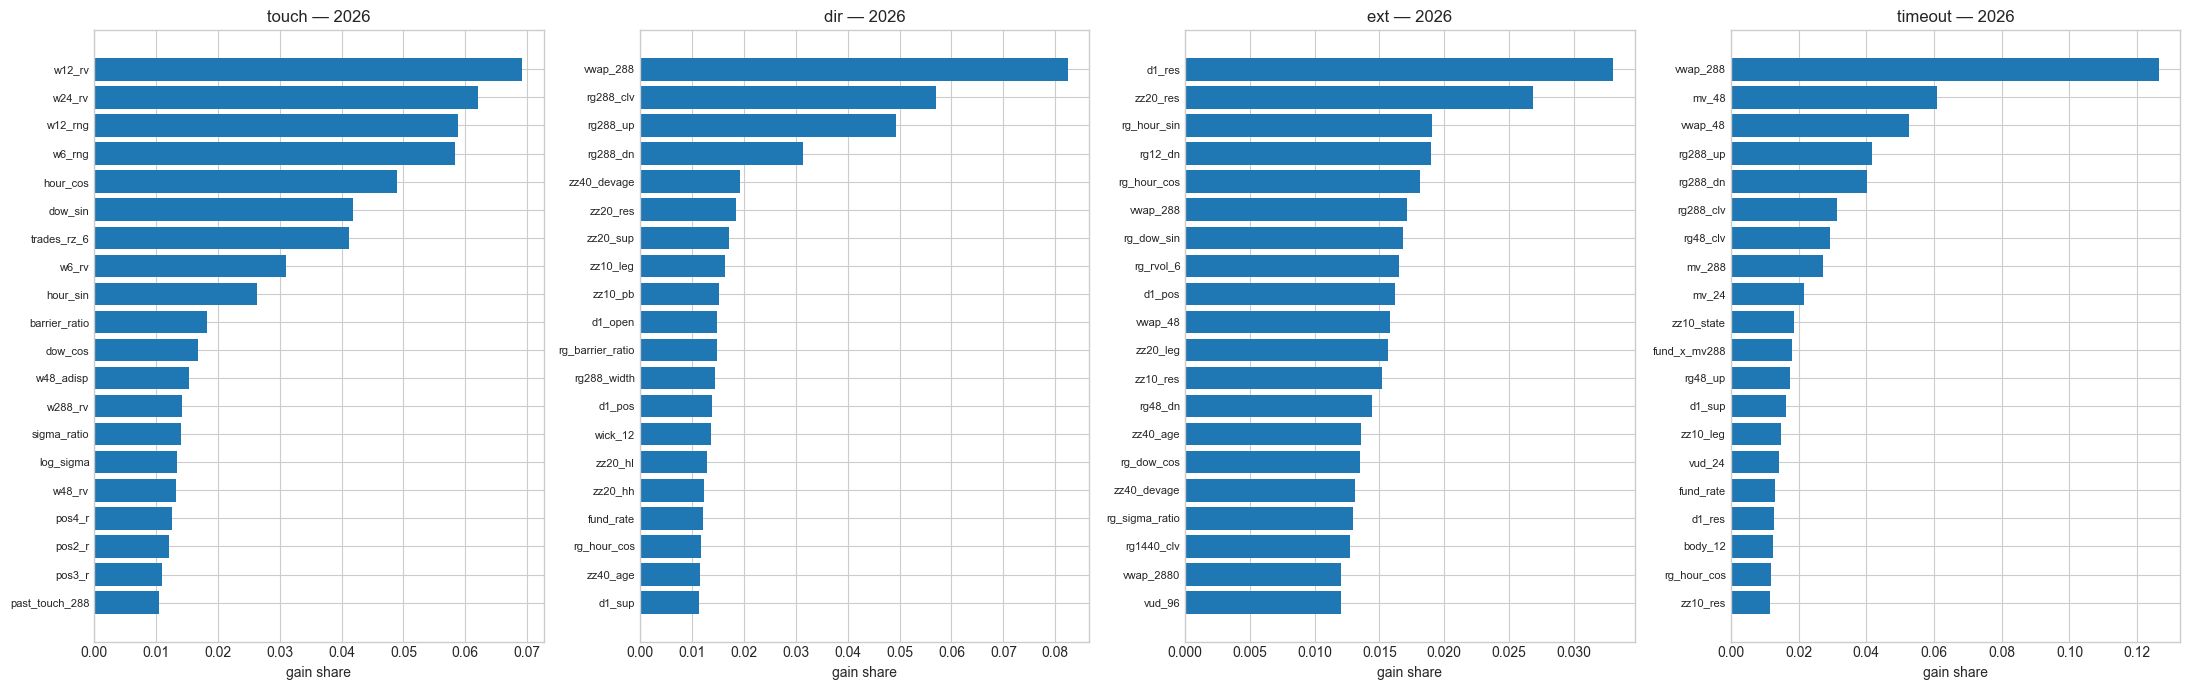

,touch,dir,ext,timeout
channel,0.009,0.000,0.000,0.000
context,0.281,0.000,0.000,0.000
dir:anchors,0.000,0.093,0.102,0.063
dir:candle,0.000,0.020,0.025,0.020
dir:flow,0.000,0.030,0.046,0.034
dir:funding,0.000,0.061,0.060,0.060
dir:move,0.000,0.053,0.094,0.171
dir:range,0.000,0.235,0.144,0.211
dir:regime,0.000,0.052,0.108,0.037
dir:structure,0.000,0.345,0.367,0.221


Feature của model dir xuất hiện trong top 25 qua các năm:


,2022,2023,2024,2025,2026,years_in_top25
vwap_288,1.0,2.0,1.0,1.0,1.0,5
rg288_up,2.0,9.0,3.0,3.0,3.0,5
rg288_dn,14.0,7.0,4.0,4.0,4.0,5
wick_12,18.0,16.0,7.0,8.0,14.0,5
d1_open,4.0,11.0,NaN,10.0,10.0,4
zz20_hh,13.0,13.0,12.0,NaN,16.0,4
zz20_hl,15.0,12.0,11.0,NaN,15.0,4
zz40_devage,21.0,NaN,10.0,7.0,5.0,4
rg1440_width,25.0,19.0,15.0,21.0,NaN,4
d1_pos,NaN,3.0,13.0,19.0,13.0,4


In [31]:
imp = fitted_by_year[last]["models"]
fig, axes = plt.subplots(1, 4, figsize=(22, 7))
for ax, (key, names) in zip(axes, (("touch", ds.touch_names), ("dir", ds.dir_names),
                                   ("ext", ds.dir_names), ("timeout", ds.dir_names))):
    s = pd.Series(imp[key][0].feature_importances_, index=names).sort_values().tail(20)
    ax.barh(s.index, s.to_numpy(), color="tab:blue")
    ax.set(title=f"{key} — {last}", xlabel="gain share")
    ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

groups = pd.DataFrame({k: pd.Series(r["importance"][k]["groups"]) for r in reports[-1:] for k in ("touch", "dir", "ext", "timeout")}).fillna(0)
display(groups.round(4).style.background_gradient(cmap="Blues", axis=0).format("{:.3f}"))

ranks = pd.DataFrame({r["fold"]: pd.Series({x["feature"]: i + 1 for i, x in enumerate(r["importance"]["dir"]["top"])})
                      for r in reports})
ranks["years_in_top25"] = ranks.notna().sum(axis=1)
print("Feature của model dir xuất hiện trong top 25 qua các năm:")
display(ranks.sort_values(["years_in_top25"] + [c for c in ranks.columns[:1]], ascending=[False, True]).head(20))

## 13. Inference từ bundle export

Load `models_final.joblib` và tính signal cho các nến đóng gần nhất bằng `mv2.predict_frame` — đúng hàm sẽ dùng cho dữ liệu live. Kiểm tra: kết quả khớp với dự báo batch, và tín hiệu đối xứng gương.

In [32]:
bundle = mv2.load_bundle(OUT / "models_final.joblib")
M = bundle["models"]

# 1) live == batch tại một nến trong năm test cuối
j = int(preds[last]["sample_id"][-1])
t_bar = int(ds.decision_idx[j])
frame = mv2.predict_frame(bundle, candles.iloc[: t_bar + 1], last_n=1)
batch = mv2.predict_signals(M, ds, np.array([j]))
diff = max(abs(frame[k].iloc[-1] - batch[k][0]) for k in ("p_touch", "p_up_touch", "e_long_1r", "e_short_2r"))
print(f"live vs batch tại {frame['timestamp'].iloc[-1]}: max diff = {diff:.2e}")
assert diff < 1e-6

# 2) đối xứng gương: long của biểu đồ gốc == short của biểu đồ gương
ids = preds[last]["sample_id"][:3000]
s = mv2.signals_from_features(M, ds.x_touch[ids], ds.x_dir[ids], ds.x_dir_mirror[ids], ds.barrier_pct[ids])
sm = mv2.signals_from_features(M, ds.x_touch[ids], ds.x_dir_mirror[ids], ds.x_dir[ids], ds.barrier_pct[ids])
print("mirror |e_long_1r - e_short_1r(mirror)| max =", float(np.abs(s["e_long_1r"] - sm["e_short_1r"]).max()))

# 3) signal của các nến mới nhất trong file dữ liệu
latest = mv2.predict_frame(bundle, candles, last_n=5)
show = ["timestamp", "close", "barrier_pct", "p_touch", "p_up_touch", "p_up_first", "p_dn_first", "p_none",
        "p_ext_long", "p_ext_short", "e_long_1r", "e_short_1r", "e_long_2r", "e_short_2r",
        "best_side", "best_rr", "best_e", "long_sl", "long_tp_1r", "long_tp_2r", "short_sl", "short_tp_1r", "short_tp_2r"]
display(latest[show].set_index("timestamp").T.round(5))
thr_last = reports[-1]["edge_thresholds_from_calibration"]["best"]
print("Ngưỡng best_e từ calibration của model cuối:", {q: round(v, 4) for q, v in thr_last.items()})
print(f"Phí tại barrier hiện tại ≈ {cfg.fee_pct_roundtrip / latest['barrier_pct'].iloc[-1]:.3f}R")

print("\nArtifacts:")
for f in sorted(OUT.iterdir()):
    print(f"  {f.name:<28} {f.stat().st_size / 1e6:8.2f} MB")

live vs batch tại 2026-10-08 15:50:00+00:00: max diff = 0.00e+00
mirror |e_long_1r - e_short_1r(mirror)| max = 2.7755575615628914e-16


timestamp,2026-10-08 19:30:00+00:00,2026-10-08 19:35:00+00:00,2026-10-08 19:40:00+00:00,2026-10-08 19:45:00+00:00,2026-10-08 19:50:00+00:00
close,81765.30000,81784.70000,81705.90000,81693.40000,81763.10000
barrier_pct,0.00966,0.00963,0.00961,0.00958,0.00956
p_touch,0.27572,0.23463,0.23985,0.21771,0.19734
p_up_touch,0.47731,0.48192,0.47884,0.47774,0.48257
p_up_first,0.13154,0.11302,0.11479,0.10396,0.09518
p_dn_first,0.14404,0.12150,0.12494,0.11364,0.10206
p_none,0.72428,0.76537,0.76015,0.78229,0.80266
p_ext_long,0.21804,0.20685,0.20094,0.19594,0.19662
p_ext_short,0.33914,0.32535,0.32293,0.31677,0.30652
e_long_1r,-0.02033,-0.01753,-0.01913,-0.01613,-0.01594


Ngưỡng best_e từ calibration của model cuối: {1.0: -0.0003, 0.5: 0.0307, 0.2: 0.061, 0.1: 0.0867, 0.05: 0.1143, 0.02: 0.145}
Phí tại barrier hiện tại ≈ 0.084R

Artifacts:
  metadata.json                    0.49 MB
  models_final.joblib              1.85 MB
  predictions_2022.npz            14.42 MB
  predictions_2023.npz            15.21 MB
  predictions_2024.npz            15.52 MB
  predictions_2025.npz            15.35 MB
  predictions_2026.npz            11.63 MB


## Ghi chú đọc kết quả

1. **Tín hiệu hướng**: nhìn `dir_auc` và CI ở mục 6. Cận dưới CI > 0.5 ở đa số năm, cùng với tỷ lệ tháng tốt ở mục 11, là điều kiện tối thiểu để tin có edge hướng.
2. **Calibration E[R]** (mục 9) phải tốt trước khi dùng `e_*` làm ngưỡng vào lệnh. Nếu `2r` lạc quan ở các decile cao thì nên ưu tiên `1r` hoặc hiệu chỉnh `p_ext`.
3. **Kinh tế học** (mục 10): edge phải vượt phí (khoảng 0,05–0,1R với phí taker). Chỉ các mức top-q có `independent_mean_net_R` > 0 ở đa số năm mới đáng đưa sang bước backtest.
4. Muốn thử cấu hình khác: đổi `OUTPUT_DIR` để không ghi đè kết quả cũ.